# Step 4b: Domain Shift Validation

**Goal:** Confirm that meaningful distribution gap exists between source and target domains.

**Key Questions:**
1. Can we classify domain from transformer features? (If accuracy >> 50%, shift exists)
2. How are features distributed across domains? (t-SNE/PCA visualization)
3. Which batches are most "domain-ambiguous"? (Hard to classify)
4. What statistical measures capture the shift? (Mean diff, covariance diff)
5. How do baseline (hand-crafted) features compare to transformer features?
6. **Does Split 2 (k-means clustering) show more domain shift than Split 1 (control mode)?**

**Contents:**
1. Setup & Feature Extraction
2. Visual Inspection of Raw Features
3. Domain Classifier Training
4. t-SNE / PCA Visualization
5. Statistical Domain Shift Measures
6. Per-Batch Analysis
7. Implications for Domain Adaptation
8. Baseline vs Transformer Feature Comparison
9. **Split 2 (Data-Driven Clustering) Analysis**

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch

from src.data_loader import load_batches
from src.domain_splits import get_control_mode_split
from src.dataset import create_dataloaders
from src.preprocessing import INPUT_FEATURES_EXPANDED as INPUT_FEATURES
from src.preprocessing import extract_early_window
from src.transformer_model import create_model, PatchTSTRegressor
from src.domain_classifier import (
    extract_features,
    extract_baseline_features,
    train_domain_classifier,
    compute_domain_statistics,
    compute_tsne_embedding,
    compute_pca_embedding,
    analyze_misclassified_batches,
)

sns.set_theme(style='whitegrid')
%matplotlib inline

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Setup & Feature Extraction

We'll use the trained transformer encoder from Step 4 to extract features from both domains.

In [2]:
# Load batches and create dataloaders
batches = load_batches()

# Use same split as step4_transformer (1c: batches 1-60 vs 61-90)
split = get_control_mode_split("1c")
source_ids = split["source"]  # 1-60 (Recipe + Operator)
target_ids = split["target"]  # 61-90 (APC)

# Use same window fraction as step4_transformer
WINDOW_FRACTION = 0.9

data = create_dataloaders(
    source_ids=source_ids,
    target_ids=target_ids,
    batches=batches,
    val_ratio=0.2,
    batch_size=8,
    window_fraction=WINDOW_FRACTION,
    seed=42,
)

print(f"Source domain: Batches {min(source_ids)}-{max(source_ids)} ({len(source_ids)} batches)")
print(f"Target domain: Batches {min(target_ids)}-{max(target_ids)} ({len(target_ids)} batches)")
print(f"\nSequence length: {data['target_len']}")
print(f"Number of features: {data['n_features']}")
print(f"Window fraction: {WINDOW_FRACTION}")

Source domain: Batches 1-60 (60 batches)
Target domain: Batches 61-90 (30 batches)

Sequence length: 1035
Number of features: 25
Window fraction: 0.9


In [3]:
# Load trained transformer model or create with current config
model_path = '../outputs/models/transformer_baseline.pt'

try:
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model = create_model(
        n_features=checkpoint['n_features'],
        seq_len=checkpoint['seq_len'],
        config=checkpoint['model_config'],
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded transformer model from {model_path}")
    print(f"  Config: d_model={checkpoint['model_config']['d_model']}, "
          f"n_layers={checkpoint['model_config']['n_layers']}")
    if 'results' in checkpoint:
        print(f"  Saved metrics: Val MAE={checkpoint['results'].get('val_mae', 'N/A'):.2f}, "
              f"Target MAE={checkpoint['results'].get('target_mae', 'N/A'):.2f}")
except FileNotFoundError:
    # Use current config from step4_transformer
    MODEL_CONFIG = {
        'patch_len': 16,
        'patch_stride': 8,
        'd_model': 32,
        'n_heads': 8,
        'n_layers': 1,
        'd_ff': 64,
        'dropout': 0.1,
        'pool': 'mean',
        'head_hidden': 32,
    }
    model = create_model(
        n_features=data['n_features'],
        seq_len=data['target_len'],
        config=MODEL_CONFIG,
    )
    print(f"Created new model with config: {MODEL_CONFIG}")
    print("Note: Model is untrained - run step4_transformer first for trained weights")

model = model.to(device)
model.eval()
print(f"\nModel ready on {device}")

Loaded transformer model from ../outputs/models/transformer_baseline.pt
  Config: d_model=32, n_layers=3
  Saved metrics: Val MAE=2.07, Target MAE=2.36

Model ready on cpu


/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/notebooks/../src/transformer_model.py:157: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [4]:
# Extract features from all splits
print("Extracting features from encoder...")

train_features, train_targets, train_domains = extract_features(model, data['train'], device)
val_features, val_targets, val_domains = extract_features(model, data['val'], device)
target_features, target_targets, target_domains = extract_features(model, data['target'], device)

# Combine source (train + val) and target
source_features = np.vstack([train_features, val_features])
source_targets = np.concatenate([train_targets, val_targets])
source_domains = np.zeros(len(source_features))  # 0 = source

all_features = np.vstack([source_features, target_features])
all_targets = np.concatenate([source_targets, target_targets])
all_domains = np.concatenate([source_domains, np.ones(len(target_features))])  # 1 = target

# Create batch ID mapping
train_ids = list(data['train'].dataset.batch_ids)
val_ids = list(data['val'].dataset.batch_ids)
target_batch_ids = list(data['target'].dataset.batch_ids)
all_batch_ids = train_ids + val_ids + target_batch_ids

print(f"\nExtracted features:")
print(f"  Source: {len(source_features)} samples, shape {source_features.shape}")
print(f"  Target: {len(target_features)} samples, shape {target_features.shape}")
print(f"  Total: {len(all_features)} samples")

Extracting features from encoder...

Extracted features:
  Source: 60 samples, shape (60, 32)
  Target: 30 samples, shape (30, 32)
  Total: 90 samples


## 2. Visual Inspection of Raw Features

Let's first look at how the raw encoder features differ between domains.

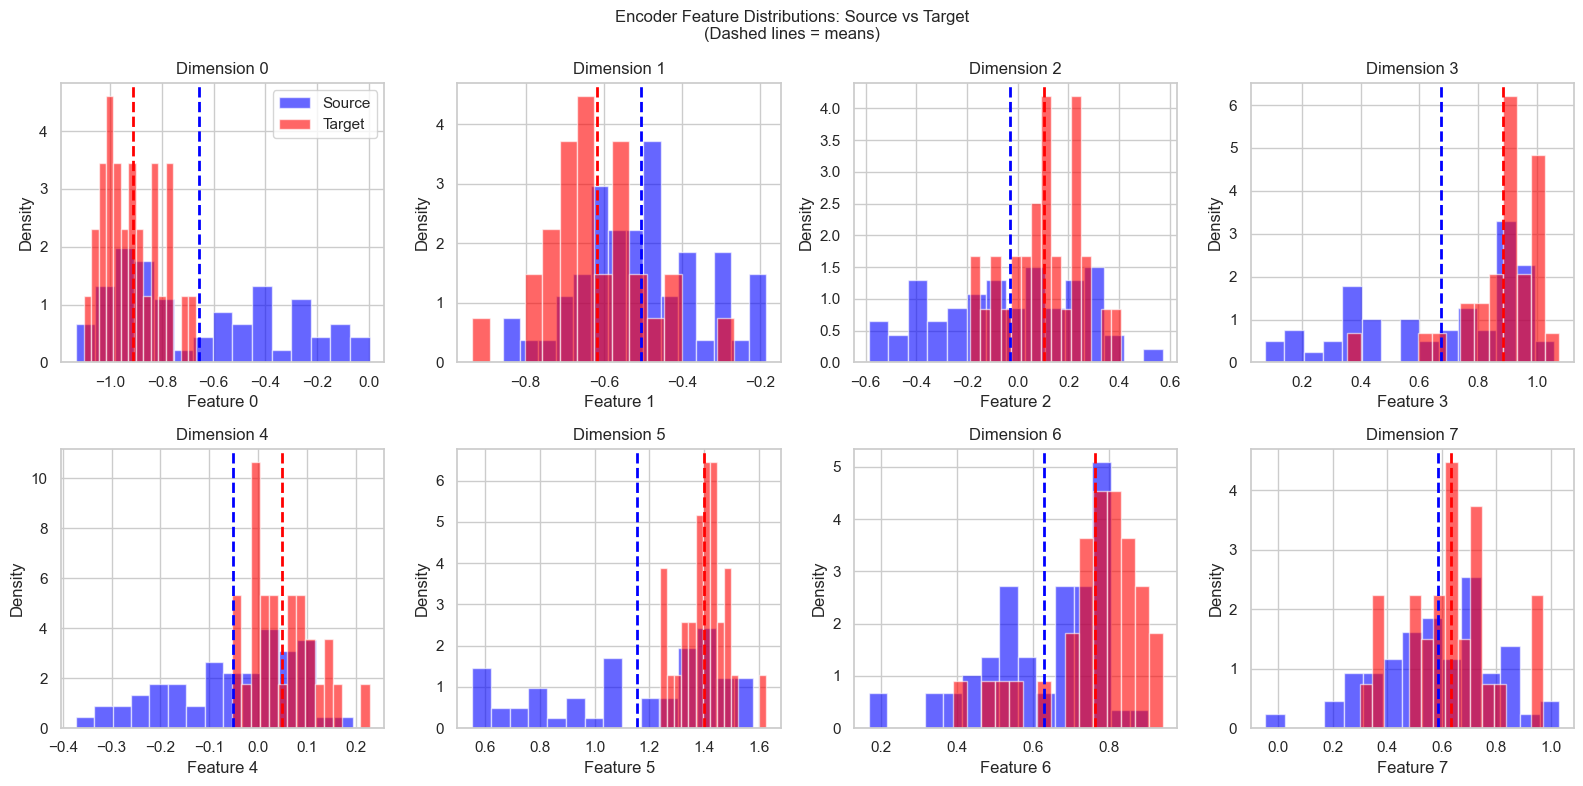

In [5]:
# Plot feature distributions for first 8 dimensions
n_dims_to_plot = 8
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx in range(n_dims_to_plot):
    ax = axes.flatten()[idx]
    
    # Plot histograms
    ax.hist(source_features[:, idx], bins=15, alpha=0.6, 
            label='Source', color='blue', density=True)
    ax.hist(target_features[:, idx], bins=15, alpha=0.6, 
            label='Target', color='red', density=True)
    
    # Add means
    ax.axvline(source_features[:, idx].mean(), color='blue', linestyle='--', linewidth=2)
    ax.axvline(target_features[:, idx].mean(), color='red', linestyle='--', linewidth=2)
    
    ax.set_xlabel(f'Feature {idx}')
    ax.set_ylabel('Density')
    ax.set_title(f'Dimension {idx}')

axes[0, 0].legend()
plt.suptitle('Encoder Feature Distributions: Source vs Target\n(Dashed lines = means)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/domain_feature_distributions.png', dpi=150)
plt.show()

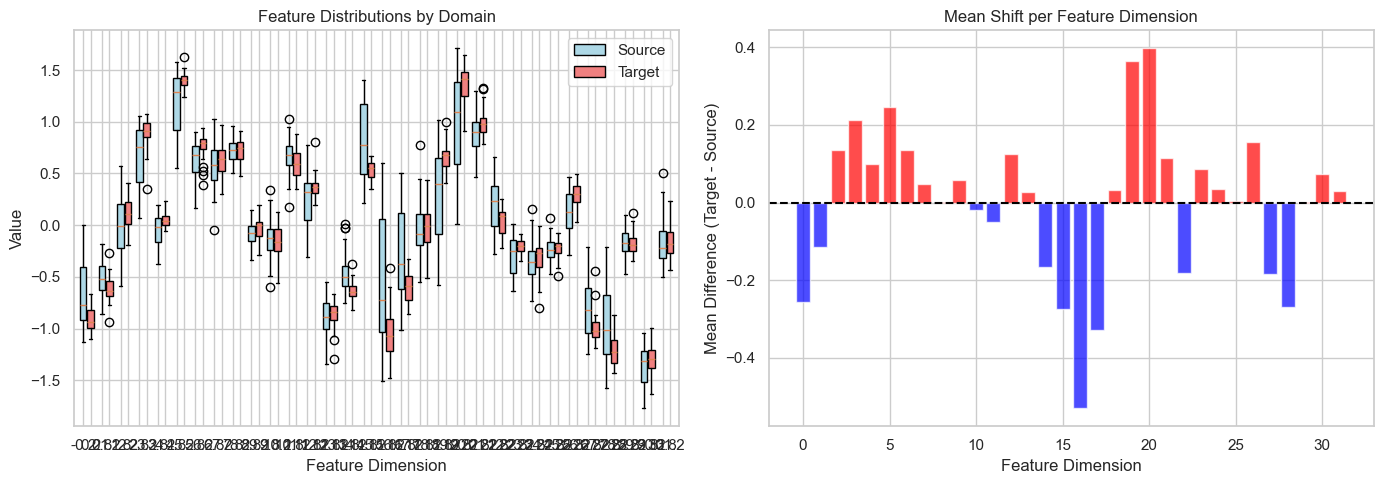

In [6]:
# Box plots comparing domains across all dimensions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Source features
ax = axes[0]
bp1 = ax.boxplot([source_features[:, i] for i in range(source_features.shape[1])],
                  positions=np.arange(source_features.shape[1]) - 0.2, widths=0.35,
                  patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')

bp2 = ax.boxplot([target_features[:, i] for i in range(target_features.shape[1])],
                  positions=np.arange(target_features.shape[1]) + 0.2, widths=0.35,
                  patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightcoral')

ax.set_xlabel('Feature Dimension')
ax.set_ylabel('Value')
ax.set_title('Feature Distributions by Domain')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Source', 'Target'])

# Mean difference per dimension
ax = axes[1]
mean_diff = target_features.mean(axis=0) - source_features.mean(axis=0)
colors = ['red' if d > 0 else 'blue' for d in mean_diff]
ax.bar(range(len(mean_diff)), mean_diff, color=colors, alpha=0.7)
ax.axhline(0, color='black', linestyle='--')
ax.set_xlabel('Feature Dimension')
ax.set_ylabel('Mean Difference (Target - Source)')
ax.set_title('Mean Shift per Feature Dimension')

plt.tight_layout()
plt.savefig('../outputs/figures/domain_feature_comparison.png', dpi=150)
plt.show()

## 3. Domain Classifier Training

Train an MLP to predict domain from encoder features. If accuracy >> 50%, the domains are distinguishable.

In [16]:
# Train domain classifier
print("Training domain classifier...\n")

classifier_results = train_domain_classifier(
    features=all_features,
    domain_labels=all_domains,
    hidden_dim=32,
    n_epochs=100,
    lr=1e-4,
    batch_size=12,
    val_ratio=0.2,
    device=device,
    verbose=True,
)

Training domain classifier...

Epoch 20/100 | Train Loss: 0.6737 | Val Loss: 0.6741 | Val Acc: 0.667
Epoch 40/100 | Train Loss: 0.6540 | Val Loss: 0.6530 | Val Acc: 0.667
Epoch 60/100 | Train Loss: 0.6418 | Val Loss: 0.6323 | Val Acc: 0.667
Epoch 80/100 | Train Loss: 0.6188 | Val Loss: 0.6112 | Val Acc: 0.667
Epoch 100/100 | Train Loss: 0.5962 | Val Loss: 0.5927 | Val Acc: 0.667

=== Domain Classification Results ===
Accuracy: 0.667
AUC: 0.753
Confusion Matrix:
[[60  0]
 [30  0]]


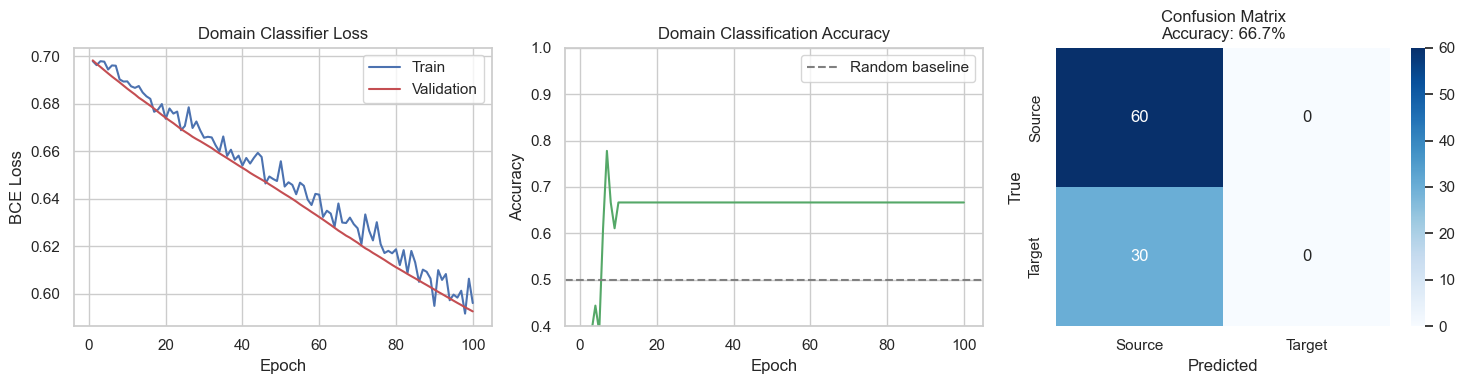

In [17]:
# Plot classifier training
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

history = classifier_results['history']
epochs = range(1, len(history['train_loss']) + 1)

# Loss
ax = axes[0]
ax.plot(epochs, history['train_loss'], 'b-', label='Train')
ax.plot(epochs, history['val_loss'], 'r-', label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Domain Classifier Loss')
ax.legend()

# Accuracy
ax = axes[1]
ax.plot(epochs, history['val_acc'], 'g-')
ax.axhline(0.5, color='gray', linestyle='--', label='Random baseline')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Domain Classification Accuracy')
ax.legend()
ax.set_ylim(0.4, 1.0)

# Confusion matrix
ax = axes[2]
conf_mat = classifier_results['confusion_matrix']
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Source', 'Target'],
            yticklabels=['Source', 'Target'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix\nAccuracy: {classifier_results["accuracy"]:.1%}')

plt.tight_layout()
plt.savefig('../outputs/figures/domain_classifier_results.png', dpi=150)
plt.show()

In [18]:
# Interpret classifier results
accuracy = classifier_results['accuracy']
auc = classifier_results['auc']

print("="*60)
print("DOMAIN SHIFT VALIDATION RESULTS")
print("="*60)
print(f"\nDomain Classification Accuracy: {accuracy:.1%}")
print(f"Domain Classification AUC: {auc:.3f}")
print(f"\nInterpretation:")
if accuracy > 0.7:
    print(f"  ✓ STRONG domain shift detected (accuracy {accuracy:.1%} >> 50%)")
    print(f"  → Domain adaptation (CORAL) is well-motivated")
elif accuracy > 0.6:
    print(f"  ~ MODERATE domain shift detected (accuracy {accuracy:.1%} > 50%)")
    print(f"  → Domain adaptation may help")
else:
    print(f"  ✗ WEAK domain shift (accuracy {accuracy:.1%} ≈ 50%)")
    print(f"  → Domains may already be similar in feature space")
print("="*60)

DOMAIN SHIFT VALIDATION RESULTS

Domain Classification Accuracy: 66.7%
Domain Classification AUC: 0.753

Interpretation:
  ~ MODERATE domain shift detected (accuracy 66.7% > 50%)
  → Domain adaptation may help


## 4. t-SNE / PCA Visualization

Visualize the feature space to see how domains cluster.

In [19]:
# Compute embeddings
print("Computing t-SNE embedding...")
tsne_embedding = compute_tsne_embedding(all_features, perplexity=15)

print("Computing PCA embedding...")
pca_embedding, pca_variance = compute_pca_embedding(all_features, n_components=2)

print(f"\nPCA explained variance: {pca_variance[0]:.1%} + {pca_variance[1]:.1%} = {pca_variance.sum():.1%}")

Computing t-SNE embedding...
Computing PCA embedding...

PCA explained variance: 69.1% + 15.5% = 84.6%


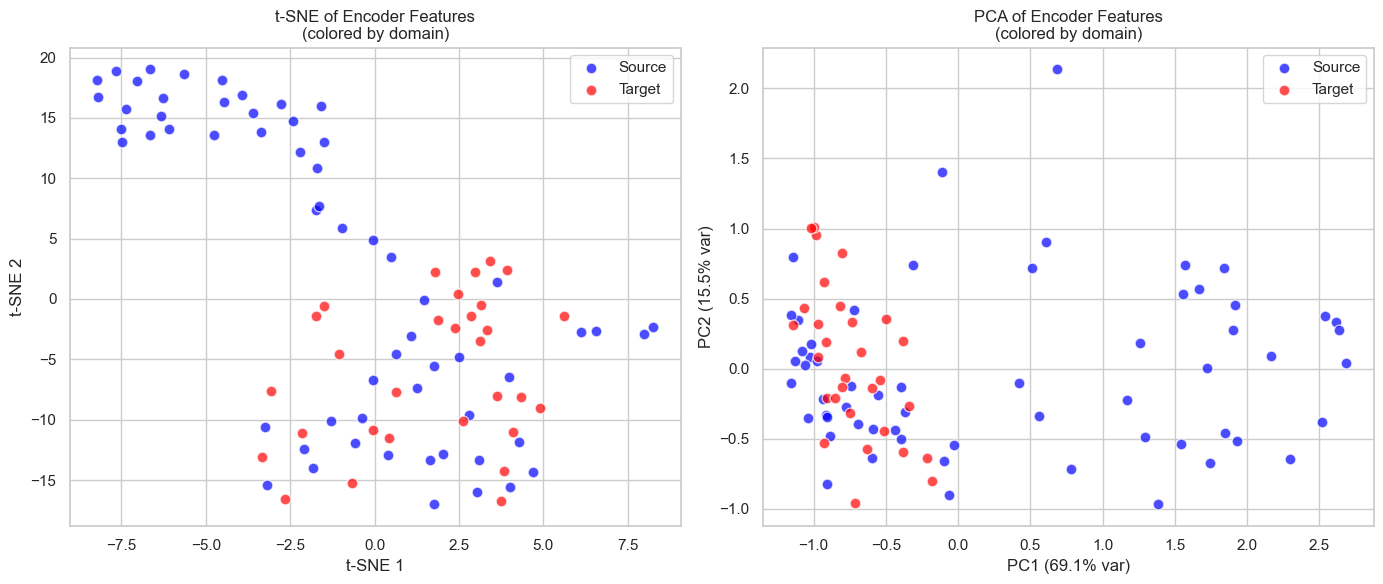

In [20]:
# Create visualization dataframe
vis_df = pd.DataFrame({
    'tsne_1': tsne_embedding[:, 0],
    'tsne_2': tsne_embedding[:, 1],
    'pca_1': pca_embedding[:, 0],
    'pca_2': pca_embedding[:, 1],
    'domain': ['Source' if d == 0 else 'Target' for d in all_domains],
    'target': all_targets,
    'batch_id': all_batch_ids,
    'domain_prob': classifier_results['probabilities'],
})

# Plot t-SNE and PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# t-SNE colored by domain
ax = axes[0]
for domain, color in [('Source', 'blue'), ('Target', 'red')]:
    mask = vis_df['domain'] == domain
    ax.scatter(vis_df.loc[mask, 'tsne_1'], vis_df.loc[mask, 'tsne_2'],
               c=color, label=domain, alpha=0.7, s=60, edgecolor='white')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE of Encoder Features\n(colored by domain)')
ax.legend()

# PCA colored by domain
ax = axes[1]
for domain, color in [('Source', 'blue'), ('Target', 'red')]:
    mask = vis_df['domain'] == domain
    ax.scatter(vis_df.loc[mask, 'pca_1'], vis_df.loc[mask, 'pca_2'],
               c=color, label=domain, alpha=0.7, s=60, edgecolor='white')
ax.set_xlabel(f'PC1 ({pca_variance[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca_variance[1]:.1%} var)')
ax.set_title('PCA of Encoder Features\n(colored by domain)')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/domain_tsne_pca.png', dpi=150)
plt.show()

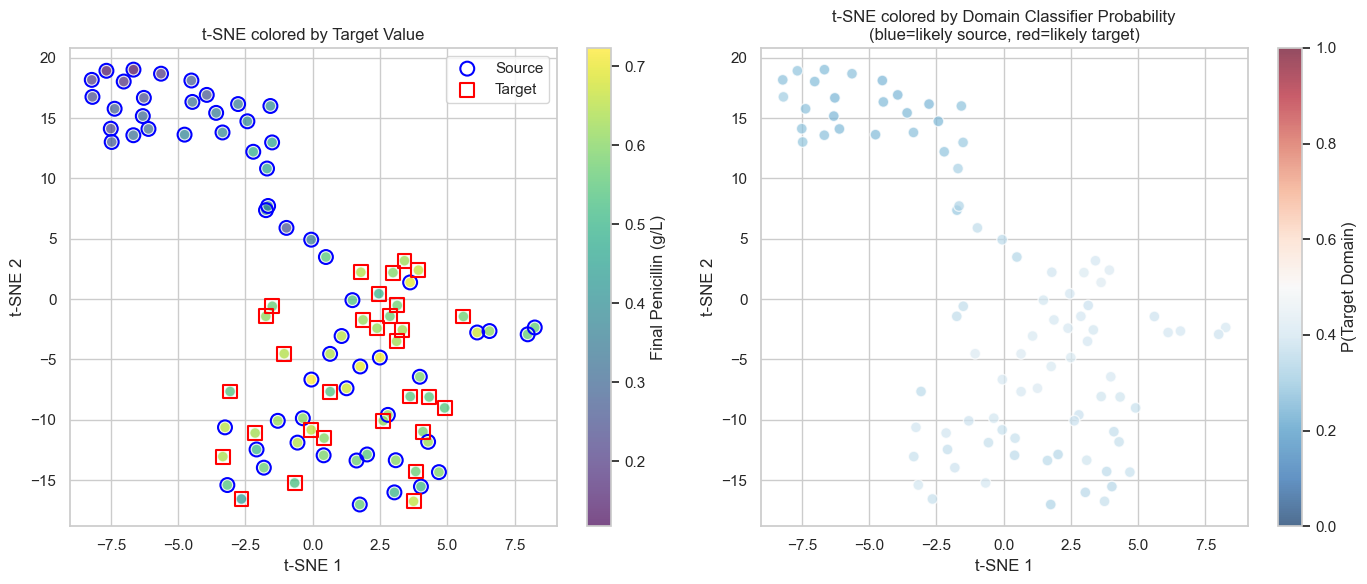

In [21]:
# Color by prediction target (penicillin concentration)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# t-SNE colored by target value
ax = axes[0]
scatter = ax.scatter(vis_df['tsne_1'], vis_df['tsne_2'],
                     c=vis_df['target'], cmap='viridis', alpha=0.7, s=60, edgecolor='white')
plt.colorbar(scatter, ax=ax, label='Final Penicillin (g/L)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE colored by Target Value')

# Mark domains with different markers
source_mask = vis_df['domain'] == 'Source'
ax.scatter(vis_df.loc[source_mask, 'tsne_1'], vis_df.loc[source_mask, 'tsne_2'],
           facecolors='none', edgecolors='blue', s=100, linewidth=1.5, label='Source')
ax.scatter(vis_df.loc[~source_mask, 'tsne_1'], vis_df.loc[~source_mask, 'tsne_2'],
           facecolors='none', edgecolors='red', s=100, linewidth=1.5, marker='s', label='Target')
ax.legend(loc='upper right')

# t-SNE colored by domain probability
ax = axes[1]
scatter = ax.scatter(vis_df['tsne_1'], vis_df['tsne_2'],
                     c=vis_df['domain_prob'], cmap='RdBu_r', alpha=0.7, s=60, edgecolor='white',
                     vmin=0, vmax=1)
plt.colorbar(scatter, ax=ax, label='P(Target Domain)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE colored by Domain Classifier Probability\n(blue=likely source, red=likely target)')

plt.tight_layout()
plt.savefig('../outputs/figures/domain_tsne_colored.png', dpi=150)
plt.show()

## 5. Statistical Domain Shift Measures

Compute quantitative measures of the distribution shift.

In [22]:
# Compute domain statistics
domain_stats = compute_domain_statistics(all_features, all_domains)

print("Domain Shift Statistics:")
print(f"  Mean normalized difference (avg): {domain_stats['mean_normalized_diff']:.3f}")
print(f"  Mean normalized difference (max): {domain_stats['max_normalized_diff']:.3f}")
print(f"  MMD approximation: {domain_stats['mmd_approx']:.4f}")
print(f"  Covariance Frobenius norm diff: {domain_stats['cov_diff_frobenius']:.3f}")

Domain Shift Statistics:
  Mean normalized difference (avg): 0.534
  Mean normalized difference (max): 0.931
  MMD approximation: 0.0385
  Covariance Frobenius norm diff: 1.638


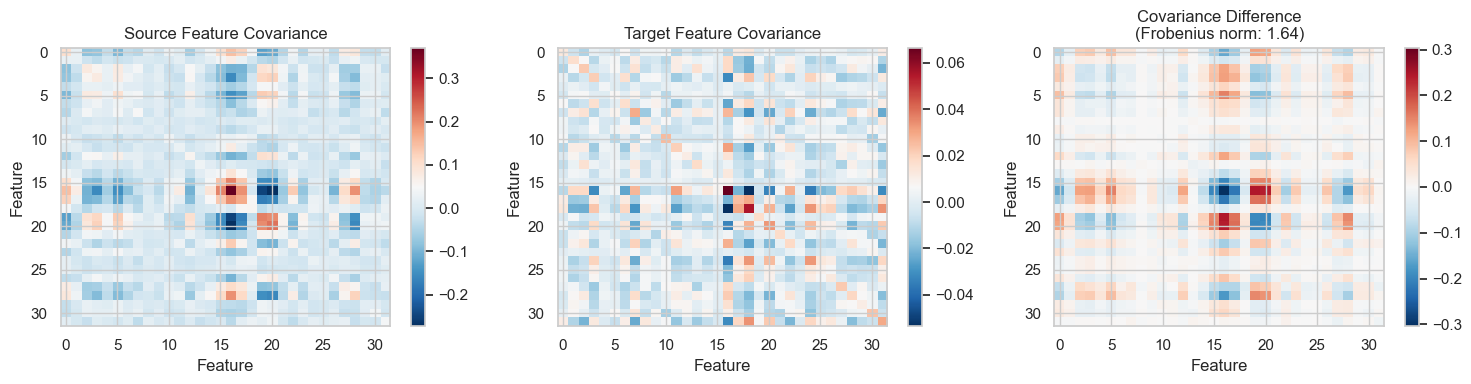

In [23]:
# Visualize covariance matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Source covariance
ax = axes[0]
im = ax.imshow(domain_stats['source_cov'], cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_title('Source Feature Covariance')
ax.set_xlabel('Feature')
ax.set_ylabel('Feature')

# Target covariance
ax = axes[1]
im = ax.imshow(domain_stats['target_cov'], cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_title('Target Feature Covariance')
ax.set_xlabel('Feature')
ax.set_ylabel('Feature')

# Difference
ax = axes[2]
cov_diff = domain_stats['target_cov'] - domain_stats['source_cov']
max_diff = np.abs(cov_diff).max()
im = ax.imshow(cov_diff, cmap='RdBu_r', aspect='auto', vmin=-max_diff, vmax=max_diff)
plt.colorbar(im, ax=ax)
ax.set_title(f'Covariance Difference\n(Frobenius norm: {domain_stats["cov_diff_frobenius"]:.2f})')
ax.set_xlabel('Feature')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig('../outputs/figures/domain_covariance_shift.png', dpi=150)
plt.show()

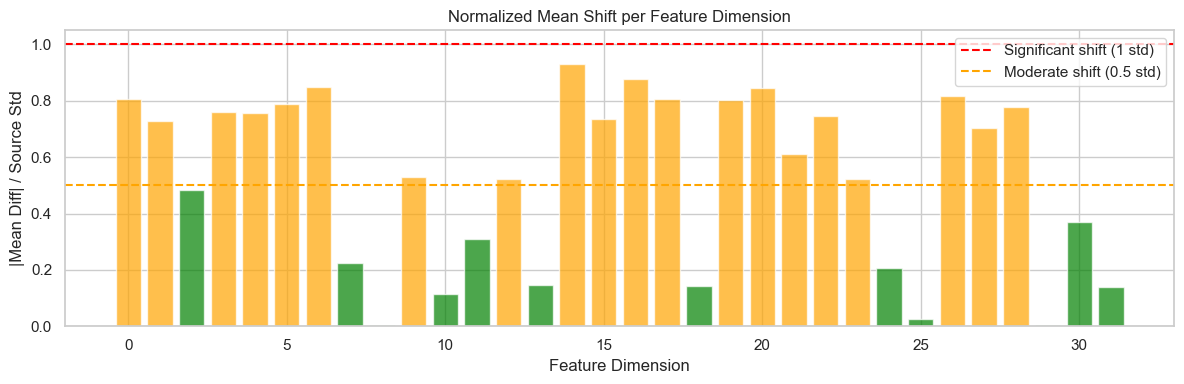


Features with significant shift (>1 std): 0/32
Features with moderate shift (0.5-1 std): 20/32


In [24]:
# Plot normalized mean difference per feature
fig, ax = plt.subplots(figsize=(12, 4))

norm_diff = domain_stats['normalized_mean_diff']
colors = ['red' if d > 1.0 else ('orange' if d > 0.5 else 'green') for d in norm_diff]

bars = ax.bar(range(len(norm_diff)), norm_diff, color=colors, alpha=0.7)
ax.axhline(1.0, color='red', linestyle='--', label='Significant shift (1 std)')
ax.axhline(0.5, color='orange', linestyle='--', label='Moderate shift (0.5 std)')

ax.set_xlabel('Feature Dimension')
ax.set_ylabel('|Mean Diff| / Source Std')
ax.set_title('Normalized Mean Shift per Feature Dimension')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/domain_normalized_shift.png', dpi=150)
plt.show()

# Count features with significant shift
n_significant = (norm_diff > 1.0).sum()
n_moderate = ((norm_diff > 0.5) & (norm_diff <= 1.0)).sum()
print(f"\nFeatures with significant shift (>1 std): {n_significant}/{len(norm_diff)}")
print(f"Features with moderate shift (0.5-1 std): {n_moderate}/{len(norm_diff)}")

## 6. Per-Batch Analysis

Identify which batches are "domain-ambiguous" (hard to classify).

In [25]:
# Analyze misclassified and uncertain batches
batch_analysis = analyze_misclassified_batches(
    classifier_results['predictions'],
    all_domains.astype(int),
    classifier_results['probabilities'],
    all_batch_ids,
)

print(f"Misclassified batches: {batch_analysis['n_misclassified']} / {len(all_domains)}")
print(f"Misclassified batch IDs: {batch_analysis['misclassified_batch_ids']}")
print(f"\nMost uncertain batches: {batch_analysis['uncertain_batch_ids']}")

Misclassified batches: 30 / 90
Misclassified batch IDs: [61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90]

Most uncertain batches: [8, 68, 62, 81, 42, 23, 53, 34, 26, 86]


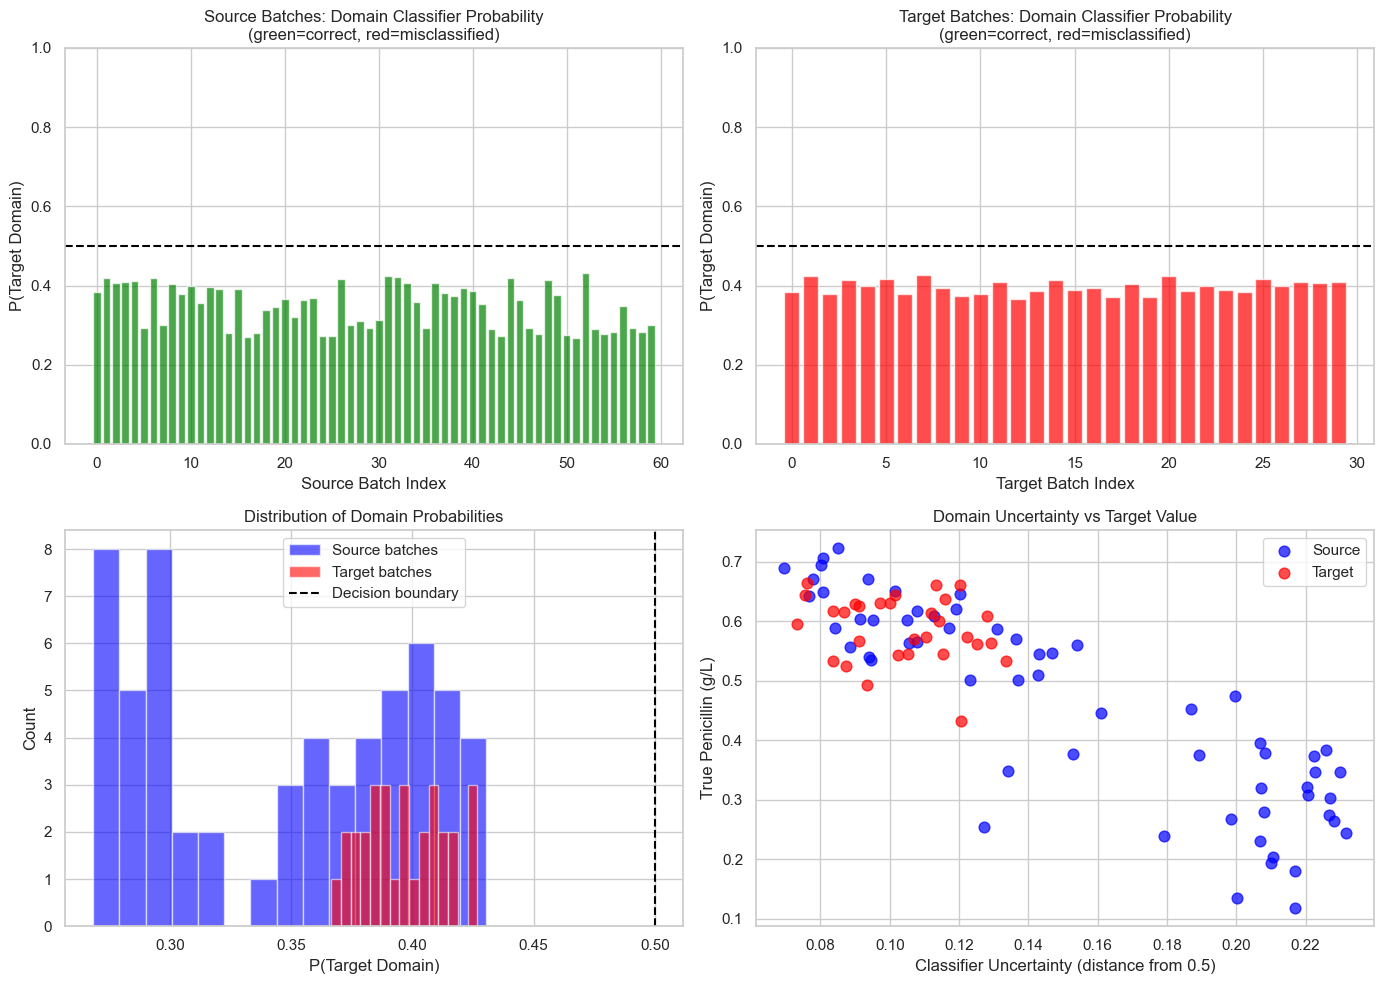

In [26]:
# Plot per-batch domain probabilities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Source batches
ax = axes[0, 0]
source_mask = all_domains == 0
source_probs = classifier_results['probabilities'][source_mask]
source_batch_ids_subset = [all_batch_ids[i] for i in range(len(all_domains)) if source_mask[i]]

colors = ['green' if p < 0.5 else 'red' for p in source_probs]
ax.bar(range(len(source_probs)), source_probs, color=colors, alpha=0.7)
ax.axhline(0.5, color='black', linestyle='--')
ax.set_xlabel('Source Batch Index')
ax.set_ylabel('P(Target Domain)')
ax.set_title('Source Batches: Domain Classifier Probability\n(green=correct, red=misclassified)')
ax.set_ylim(0, 1)

# Target batches
ax = axes[0, 1]
target_mask = all_domains == 1
target_probs = classifier_results['probabilities'][target_mask]

colors = ['green' if p > 0.5 else 'red' for p in target_probs]
ax.bar(range(len(target_probs)), target_probs, color=colors, alpha=0.7)
ax.axhline(0.5, color='black', linestyle='--')
ax.set_xlabel('Target Batch Index')
ax.set_ylabel('P(Target Domain)')
ax.set_title('Target Batches: Domain Classifier Probability\n(green=correct, red=misclassified)')
ax.set_ylim(0, 1)

# Histogram of domain probabilities
ax = axes[1, 0]
ax.hist(source_probs, bins=15, alpha=0.6, label='Source batches', color='blue')
ax.hist(target_probs, bins=15, alpha=0.6, label='Target batches', color='red')
ax.axvline(0.5, color='black', linestyle='--', label='Decision boundary')
ax.set_xlabel('P(Target Domain)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Domain Probabilities')
ax.legend()

# Relationship between domain prob and prediction error
ax = axes[1, 1]

# Load transformer predictions
checkpoint = torch.load('../outputs/models/transformer_baseline.pt', map_location='cpu', weights_only=False)
vis_df['domain_prob'] = classifier_results['probabilities']

# Scatter: domain probability vs distance from decision boundary
uncertainty = np.abs(classifier_results['probabilities'] - 0.5)
ax.scatter(uncertainty[source_mask], all_targets[source_mask], 
           c='blue', alpha=0.7, label='Source', s=60)
ax.scatter(uncertainty[target_mask], all_targets[target_mask], 
           c='red', alpha=0.7, label='Target', s=60)
ax.set_xlabel('Classifier Uncertainty (distance from 0.5)')
ax.set_ylabel('True Penicillin (g/L)')
ax.set_title('Domain Uncertainty vs Target Value')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/domain_batch_analysis.png', dpi=150)
plt.show()

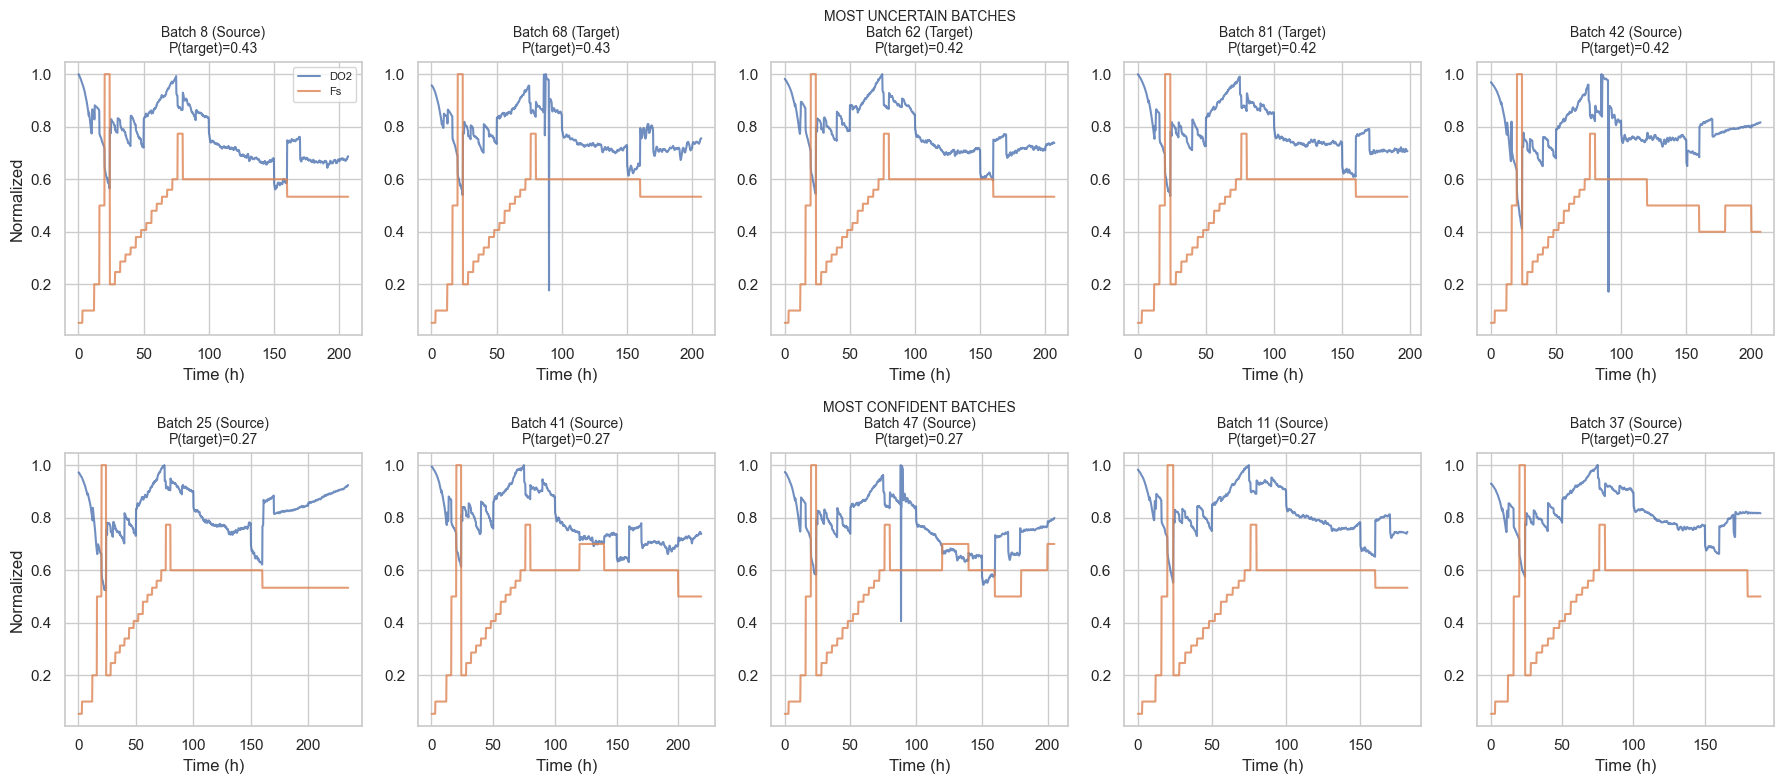

In [27]:
# Show input signals for most ambiguous batches
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# Get 5 most uncertain batches
uncertainty = np.abs(classifier_results['probabilities'] - 0.5)
most_uncertain_idx = np.argsort(uncertainty)[:5]

# Get 5 most confident correct classifications
correct_mask = classifier_results['predictions'] == all_domains.astype(int)
confident_correct_idx = np.argsort(uncertainty[correct_mask])[::-1][:5]
confident_correct_global_idx = np.where(correct_mask)[0][confident_correct_idx]

# Plot uncertain batches (top row)
for col, idx in enumerate(most_uncertain_idx):
    ax = axes[0, col]
    batch_id = all_batch_ids[idx]
    batch_df = batches[batch_id]
    early = extract_early_window(batch_df, WINDOW_FRACTION)
    
    # Plot key signals
    ax.plot(early['time'], early['DO2'] / early['DO2'].max(), label='DO2', alpha=0.8)
    ax.plot(early['time'], early['Fs'] / (early['Fs'].max() + 1e-6), label='Fs', alpha=0.8)
    
    domain_str = 'Source' if all_domains[idx] == 0 else 'Target'
    prob = classifier_results['probabilities'][idx]
    ax.set_title(f'Batch {batch_id} ({domain_str})\nP(target)={prob:.2f}', fontsize=10)
    ax.set_xlabel('Time (h)')
    if col == 0:
        ax.set_ylabel('Normalized')
        ax.legend(fontsize=8)

# Plot confident batches (bottom row)
for col, idx in enumerate(confident_correct_global_idx):
    ax = axes[1, col]
    batch_id = all_batch_ids[idx]
    batch_df = batches[batch_id]
    early = extract_early_window(batch_df, WINDOW_FRACTION)
    
    ax.plot(early['time'], early['DO2'] / early['DO2'].max(), label='DO2', alpha=0.8)
    ax.plot(early['time'], early['Fs'] / (early['Fs'].max() + 1e-6), label='Fs', alpha=0.8)
    
    domain_str = 'Source' if all_domains[idx] == 0 else 'Target'
    prob = classifier_results['probabilities'][idx]
    ax.set_title(f'Batch {batch_id} ({domain_str})\nP(target)={prob:.2f}', fontsize=10)
    ax.set_xlabel('Time (h)')
    if col == 0:
        ax.set_ylabel('Normalized')

axes[0, 2].set_title('MOST UNCERTAIN BATCHES\n' + axes[0, 2].get_title(), fontsize=10)
axes[1, 2].set_title('MOST CONFIDENT BATCHES\n' + axes[1, 2].get_title(), fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/domain_ambiguous_batches.png', dpi=150)
plt.show()

## 7. Implications for Domain Adaptation

Summarize findings and implications for CORAL adaptation.

In [28]:
# Create summary table
summary_data = {
    'Metric': [
        'Domain Classification Accuracy',
        'Domain Classification AUC',
        'Mean Normalized Feature Shift',
        'Max Normalized Feature Shift',
        'Covariance Difference (Frobenius)',
        'Features with >1 std shift',
        'Misclassified Batches',
    ],
    'Value': [
        f"{classifier_results['accuracy']:.1%}",
        f"{classifier_results['auc']:.3f}",
        f"{domain_stats['mean_normalized_diff']:.3f}",
        f"{domain_stats['max_normalized_diff']:.3f}",
        f"{domain_stats['cov_diff_frobenius']:.2f}",
        f"{(domain_stats['normalized_mean_diff'] > 1.0).sum()}/{len(domain_stats['normalized_mean_diff'])}",
        f"{batch_analysis['n_misclassified']}/{len(all_domains)}",
    ],
    'Interpretation': [
        'Strong' if classifier_results['accuracy'] > 0.7 else 'Moderate' if classifier_results['accuracy'] > 0.6 else 'Weak',
        'Good separation' if classifier_results['auc'] > 0.7 else 'Some overlap',
        'High' if domain_stats['mean_normalized_diff'] > 0.5 else 'Low',
        'Some features very different' if domain_stats['max_normalized_diff'] > 1.0 else 'Similar',
        'Significant covariance shift' if domain_stats['cov_diff_frobenius'] > 10 else 'Minor',
        'Domain adaptation target',
        'Classifier errors',
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("DOMAIN SHIFT VALIDATION SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


DOMAIN SHIFT VALIDATION SUMMARY
                           Metric Value           Interpretation
   Domain Classification Accuracy 66.7%                 Moderate
        Domain Classification AUC 0.753          Good separation
    Mean Normalized Feature Shift 0.534                     High
     Max Normalized Feature Shift 0.931                  Similar
Covariance Difference (Frobenius)  1.64                    Minor
       Features with >1 std shift  0/32 Domain adaptation target
            Misclassified Batches 30/90        Classifier errors


In [29]:
# Save summary
summary_df.to_csv('../outputs/domain_shift_summary.csv', index=False)
print("\nSaved domain shift summary to outputs/domain_shift_summary.csv")

# Save detailed results
vis_df.to_csv('../outputs/domain_shift_details.csv', index=False)
print("Saved per-batch details to outputs/domain_shift_details.csv")


Saved domain shift summary to outputs/domain_shift_summary.csv
Saved per-batch details to outputs/domain_shift_details.csv


## 8. Baseline vs Transformer Feature Comparison

**Key Question:** Which feature representation shows more domain shift?

This comparison helps us understand:
- If baseline features have high domain classification accuracy → domain shift exists in raw statistics
- If transformer features have lower accuracy → transformer learned to ignore domain-specific patterns
- If both are similar → the domain shift (or lack thereof) is inherent to the data

In [30]:
# Extract baseline features (hand-crafted statistics)
print("Extracting baseline features (5 stats × 11 variables = 55 dims)...")

# Get batch IDs for source and target (use same as transformer)
source_batch_ids = list(source_ids)
target_batch_ids_base = list(target_ids)

# Extract features using same window fraction as transformer
baseline_source_features, feature_names = extract_baseline_features(
    batches, source_batch_ids, INPUT_FEATURES, window_fraction=WINDOW_FRACTION
)
baseline_target_features, _ = extract_baseline_features(
    batches, target_batch_ids_base, INPUT_FEATURES, window_fraction=WINDOW_FRACTION
)

# Combine for domain classification
baseline_all_features = np.vstack([baseline_source_features, baseline_target_features])
baseline_all_domains = np.concatenate([
    np.zeros(len(baseline_source_features)),  # 0 = source
    np.ones(len(baseline_target_features))    # 1 = target
])

print(f"\nBaseline features extracted:")
print(f"  Source: {baseline_source_features.shape}")
print(f"  Target: {baseline_target_features.shape}")
print(f"  Total features: {len(feature_names)}")
print(f"  Window fraction: {WINDOW_FRACTION}")
print(f"  Feature names (first 10): {feature_names[:10]}")

Extracting baseline features (5 stats × 11 variables = 55 dims)...

Baseline features extracted:
  Source: (60, 125)
  Target: (30, 125)
  Total features: 125
  Window fraction: 0.9
  Feature names (first 10): ['Fg_mean', 'Fg_std', 'Fg_min', 'Fg_max', 'Fg_slope', 'Fs_mean', 'Fs_std', 'Fs_min', 'Fs_max', 'Fs_slope']


In [31]:
# Train domain classifier on baseline features
print("Training domain classifier on baseline features...\n")

baseline_classifier_results = train_domain_classifier(
    features=baseline_all_features,
    domain_labels=baseline_all_domains,
    hidden_dim=32,
    n_epochs=100,
    lr=1e-3,
    batch_size=16,
    val_ratio=0.2,
    device=device,
    verbose=True,
)

Training domain classifier on baseline features...

Epoch 20/100 | Train Loss: 40.9672 | Val Loss: 37.0146 | Val Acc: 0.556
Epoch 40/100 | Train Loss: 0.6836 | Val Loss: 0.6892 | Val Acc: 0.556
Epoch 60/100 | Train Loss: 0.4002 | Val Loss: 0.5464 | Val Acc: 0.556
Epoch 80/100 | Train Loss: 0.4602 | Val Loss: 0.5332 | Val Acc: 0.556
Epoch 100/100 | Train Loss: 0.4318 | Val Loss: 0.5669 | Val Acc: 0.556

=== Domain Classification Results ===
Accuracy: 0.667
AUC: 0.877
Confusion Matrix:
[[60  0]
 [30  0]]


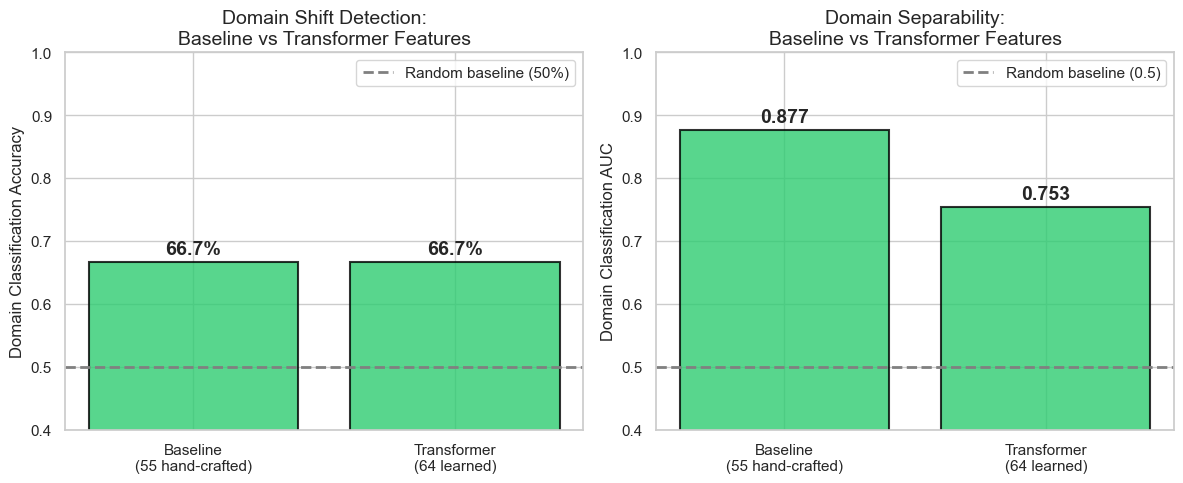

In [32]:
# Compare domain classification accuracy: Baseline vs Transformer
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart comparison
ax = axes[0]
methods = ['Baseline\n(55 hand-crafted)', 'Transformer\n(64 learned)']
accuracies = [baseline_classifier_results['accuracy'], classifier_results['accuracy']]
colors = ['#2ecc71' if acc > 0.6 else '#e74c3c' if acc < 0.55 else '#f39c12' for acc in accuracies]

bars = ax.bar(methods, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=2, label='Random baseline (50%)')
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Domain Classification Accuracy', fontsize=12)
ax.set_title('Domain Shift Detection:\nBaseline vs Transformer Features', fontsize=14)
ax.legend(loc='upper right')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.annotate(f'{acc:.1%}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=14, fontweight='bold')

# AUC comparison
ax = axes[1]
aucs = [baseline_classifier_results['auc'], classifier_results['auc']]
bars = ax.bar(methods, aucs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=2, label='Random baseline (0.5)')
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Domain Classification AUC', fontsize=12)
ax.set_title('Domain Separability:\nBaseline vs Transformer Features', fontsize=14)
ax.legend(loc='upper right')

for bar, auc in zip(bars, aucs):
    height = bar.get_height()
    ax.annotate(f'{auc:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/domain_baseline_vs_transformer.png', dpi=150)
plt.show()

Computing t-SNE for baseline features...


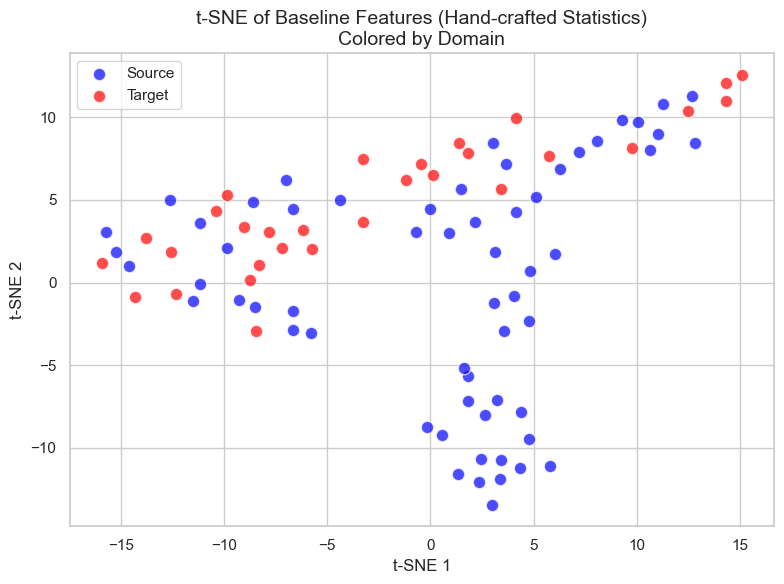

In [33]:
# Compute t-SNE for baseline features
print("Computing t-SNE for baseline features...")
baseline_tsne = compute_tsne_embedding(baseline_all_features, perplexity=15)

# Plot baseline t-SNE
fig, ax = plt.subplots(figsize=(8, 6))

for domain, color, label in [(0, 'blue', 'Source'), (1, 'red', 'Target')]:
    mask = baseline_all_domains == domain
    ax.scatter(baseline_tsne[mask, 0], baseline_tsne[mask, 1],
               c=color, label=label, alpha=0.7, s=80, edgecolor='white')

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE of Baseline Features (Hand-crafted Statistics)\nColored by Domain', fontsize=14)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/figures/domain_baseline_tsne.png', dpi=150)
plt.show()

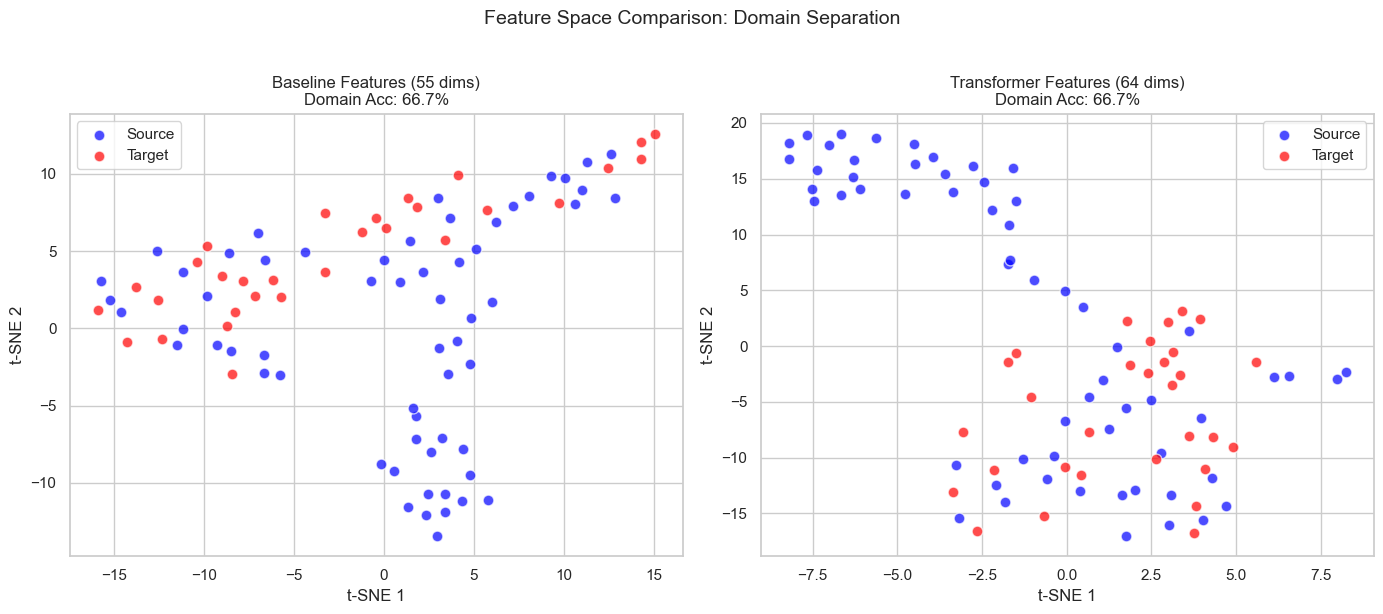

In [34]:
# Side-by-side t-SNE comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Baseline t-SNE
ax = axes[0]
for domain, color, label in [(0, 'blue', 'Source'), (1, 'red', 'Target')]:
    mask = baseline_all_domains == domain
    ax.scatter(baseline_tsne[mask, 0], baseline_tsne[mask, 1],
               c=color, label=label, alpha=0.7, s=60, edgecolor='white')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'Baseline Features (55 dims)\nDomain Acc: {baseline_classifier_results["accuracy"]:.1%}', fontsize=12)
ax.legend()

# Transformer t-SNE (reuse from earlier)
ax = axes[1]
for domain, color, label in [('Source', 'blue', 'Source'), ('Target', 'red', 'Target')]:
    mask = vis_df['domain'] == domain
    ax.scatter(vis_df.loc[mask, 'tsne_1'], vis_df.loc[mask, 'tsne_2'],
               c=color, label=label, alpha=0.7, s=60, edgecolor='white')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'Transformer Features (64 dims)\nDomain Acc: {classifier_results["accuracy"]:.1%}', fontsize=12)
ax.legend()

plt.suptitle('Feature Space Comparison: Domain Separation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/domain_feature_comparison_summary.png', dpi=150)
plt.show()

In [35]:
# Compute domain statistics for baseline features
baseline_domain_stats = compute_domain_statistics(baseline_all_features, baseline_all_domains)

# Create comparison summary table
comparison_data = {
    'Metric': [
        'Feature Dimensions',
        'Domain Classification Accuracy',
        'Domain Classification AUC',
        'Mean Normalized Shift',
        'Max Normalized Shift', 
        'Covariance Diff (Frobenius)',
    ],
    'Baseline Features': [
        f"{baseline_all_features.shape[1]}",
        f"{baseline_classifier_results['accuracy']:.1%}",
        f"{baseline_classifier_results['auc']:.3f}",
        f"{baseline_domain_stats['mean_normalized_diff']:.3f}",
        f"{baseline_domain_stats['max_normalized_diff']:.3f}",
        f"{baseline_domain_stats['cov_diff_frobenius']:.2f}",
    ],
    'Transformer Features': [
        f"{all_features.shape[1]}",
        f"{classifier_results['accuracy']:.1%}",
        f"{classifier_results['auc']:.3f}",
        f"{domain_stats['mean_normalized_diff']:.3f}",
        f"{domain_stats['max_normalized_diff']:.3f}",
        f"{domain_stats['cov_diff_frobenius']:.2f}",
    ],
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("BASELINE VS TRANSFORMER FEATURE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Save comparison
comparison_df.to_csv('../outputs/domain_baseline_vs_transformer.csv', index=False)
print("\nSaved comparison to outputs/domain_baseline_vs_transformer.csv")


BASELINE VS TRANSFORMER FEATURE COMPARISON
                        Metric Baseline Features Transformer Features
            Feature Dimensions               125                   32
Domain Classification Accuracy             66.7%                66.7%
     Domain Classification AUC             0.877                0.753
         Mean Normalized Shift             0.434                0.534
          Max Normalized Shift             6.560                0.931
   Covariance Diff (Frobenius)       26811444.99                 1.64

Saved comparison to outputs/domain_baseline_vs_transformer.csv


In [37]:
# Interpretation of comparison results
baseline_acc = baseline_classifier_results['accuracy']
transformer_acc = classifier_results['accuracy']

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)

if baseline_acc > 0.6 and transformer_acc < 0.6:
    print("""
FINDING: Baseline features show MORE domain shift than transformer features.

This suggests the transformer has learned domain-invariant representations:
- Hand-crafted statistics capture domain-specific patterns (control modes differ)
- The transformer encoder abstracts away these domain-specific details
- CORAL may have limited benefit since transformer already reduces shift

IMPLICATION: The performance gap on target domain may be due to:
- Label distribution shift (different penicillin concentrations)
- Task-relevant features that vary by domain
- Not just feature distribution shift
""")
elif baseline_acc < 0.6 and transformer_acc > 0.6:
    print("""
FINDING: Transformer features show MORE domain shift than baseline features.

This suggests the transformer is capturing domain-specific patterns:
- The encoder may be encoding control mode information
- CORAL loss could help align these learned representations
- Domain adaptation is well-motivated for this model

IMPLICATION: Applying CORAL to transformer features should help reduce
the performance gap between source and target domains.
""")
elif baseline_acc < 0.6 and transformer_acc < 0.6:
    print("""
FINDING: BOTH feature representations show WEAK domain shift.

This suggests domains are inherently similar in feature space:
- Control mode differences may not manifest in early-window patterns
- The 50% accuracy means domains are indistinguishable
- Domain adaptation (CORAL) may not be necessary or beneficial

IMPLICATION: Performance gaps likely come from label shift or
factors beyond feature distribution alignment.
""")
else:
    print("""
FINDING: BOTH feature representations show domain shift.

This suggests domain shift exists at multiple levels:
- Both raw statistics and learned features differ across domains
- CORAL could help align either representation
- May need to consider label shift in addition to feature shift

IMPLICATION: Domain adaptation could help, but consider whether
the shift is in features relevant to the prediction task.
""")

print("="*80)


INTERPRETATION

FINDING: BOTH feature representations show domain shift.

This suggests domain shift exists at multiple levels:
- Both raw statistics and learned features differ across domains
- CORAL could help align either representation
- May need to consider label shift in addition to feature shift

IMPLICATION: Domain adaptation could help, but consider whether
the shift is in features relevant to the prediction task.



## 9. Split 2 (Data-Driven Clustering) Analysis

Evaluate whether the k-means clustering split shows more meaningful domain shift than control mode.

In [39]:
# Load Split 2 assignments (k-means clustering)
import json

with open('../outputs/split_assignments.json', 'r') as f:
    split_assignments = json.load(f)

split2_source_ids = split_assignments['clustering']['source']
split2_target_ids = split_assignments['clustering']['target']

print("Split 2 (K-means Clustering):")
print(f"  Source: {len(split2_source_ids)} batches")
print(f"  Target: {len(split2_target_ids)} batches")
print(f"  Imbalance ratio: {len(split2_source_ids)/len(split2_target_ids):.1f}:1")
print(f"\n  Source batch IDs: {split2_source_ids[:10]}... (first 10)")
print(f"  Target batch IDs: {split2_target_ids}")

Split 2 (K-means Clustering):
  Source: 71 batches
  Target: 19 batches
  Imbalance ratio: 3.7:1

  Source batch IDs: [1, 2, 3, 4, 6, 7, 8, 9, 10, 12]... (first 10)
  Target batch IDs: [5, 11, 13, 15, 17, 19, 27, 35, 37, 53, 55, 59, 67, 71, 75, 77, 81, 85, 87]


In [40]:
# Create dataloaders for Split 2
# Note: Using the same transformer model trained on Split 1 source domain

data_split2 = create_dataloaders(
    source_ids=split2_source_ids,
    target_ids=split2_target_ids,
    batches=batches,
    val_ratio=0.2,
    batch_size=8,
    window_fraction=WINDOW_FRACTION,  # Use same as Split 1
    seed=42,
)

print(f"Split 2 DataLoaders created:")
print(f"  Train (source): {len(data_split2['train'].dataset)} samples")
print(f"  Val (source): {len(data_split2['val'].dataset)} samples")
print(f"  Target: {len(data_split2['target'].dataset)} samples")
print(f"  Window fraction: {WINDOW_FRACTION}")

Split 2 DataLoaders created:
  Train (source): 57 samples
  Val (source): 14 samples
  Target: 19 samples
  Window fraction: 0.9


In [41]:
# Extract transformer features for Split 2
print("Extracting transformer features for Split 2...")

split2_train_features, split2_train_targets, _ = extract_features(model, data_split2['train'], device)
split2_val_features, split2_val_targets, _ = extract_features(model, data_split2['val'], device)
split2_target_features, split2_target_targets, _ = extract_features(model, data_split2['target'], device)

# Combine source (train + val) and target
split2_source_features = np.vstack([split2_train_features, split2_val_features])
split2_source_targets = np.concatenate([split2_train_targets, split2_val_targets])

split2_all_features = np.vstack([split2_source_features, split2_target_features])
split2_all_targets = np.concatenate([split2_source_targets, split2_target_targets])
split2_all_domains = np.concatenate([
    np.zeros(len(split2_source_features)),  # 0 = source
    np.ones(len(split2_target_features))    # 1 = target
])

# Batch IDs for Split 2
split2_train_batch_ids = list(data_split2['train'].dataset.batch_ids)
split2_val_batch_ids = list(data_split2['val'].dataset.batch_ids)
split2_target_batch_ids = list(data_split2['target'].dataset.batch_ids)
split2_all_batch_ids = split2_train_batch_ids + split2_val_batch_ids + split2_target_batch_ids

print(f"\nSplit 2 features extracted:")
print(f"  Source: {split2_source_features.shape}")
print(f"  Target: {split2_target_features.shape}")
print(f"  Total: {split2_all_features.shape}")

Extracting transformer features for Split 2...

Split 2 features extracted:
  Source: (71, 32)
  Target: (19, 32)
  Total: (90, 32)


In [42]:
# Train domain classifier on Split 2 transformer features
print("Training domain classifier on Split 2 features...\n")

split2_classifier_results = train_domain_classifier(
    features=split2_all_features,
    domain_labels=split2_all_domains,
    hidden_dim=32,
    n_epochs=100,
    lr=1e-3,
    batch_size=16,
    val_ratio=0.2,
    device=device,
    verbose=True,
)

Training domain classifier on Split 2 features...

Epoch 20/100 | Train Loss: 0.4665 | Val Loss: 0.4922 | Val Acc: 0.778
Epoch 40/100 | Train Loss: 0.4572 | Val Loss: 0.4239 | Val Acc: 0.778
Epoch 60/100 | Train Loss: 0.4343 | Val Loss: 0.3499 | Val Acc: 0.778
Epoch 80/100 | Train Loss: 0.3633 | Val Loss: 0.2796 | Val Acc: 0.833
Epoch 100/100 | Train Loss: 0.3174 | Val Loss: 0.2234 | Val Acc: 0.889

=== Domain Classification Results ===
Accuracy: 0.878
AUC: 0.904
Confusion Matrix:
[[71  0]
 [11  8]]


In [43]:
# Compute domain statistics for Split 2
split2_domain_stats = compute_domain_statistics(split2_all_features, split2_all_domains)

print("Split 2 Domain Shift Statistics:")
print(f"  Mean normalized difference (avg): {split2_domain_stats['mean_normalized_diff']:.3f}")
print(f"  Mean normalized difference (max): {split2_domain_stats['max_normalized_diff']:.3f}")
print(f"  MMD approximation: {split2_domain_stats['mmd_approx']:.4f}")
print(f"  Covariance Frobenius norm diff: {split2_domain_stats['cov_diff_frobenius']:.3f}")

Split 2 Domain Shift Statistics:
  Mean normalized difference (avg): 0.450
  Mean normalized difference (max): 1.276
  MMD approximation: 0.0160
  Covariance Frobenius norm diff: 0.929


Computing t-SNE for Split 2...


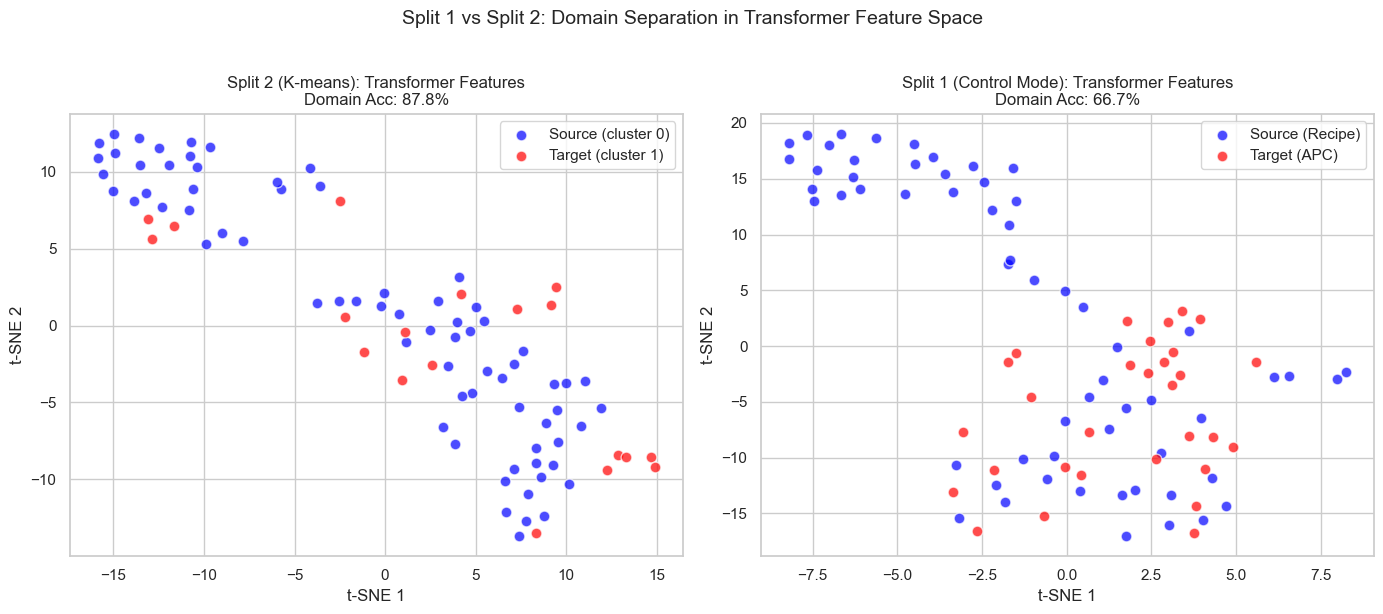

In [44]:
# t-SNE visualization for Split 2
print("Computing t-SNE for Split 2...")
split2_tsne = compute_tsne_embedding(split2_all_features, perplexity=15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Split 2 t-SNE
ax = axes[0]
for domain, color, label in [(0, 'blue', 'Source (cluster 0)'), (1, 'red', 'Target (cluster 1)')]:
    mask = split2_all_domains == domain
    ax.scatter(split2_tsne[mask, 0], split2_tsne[mask, 1],
               c=color, label=label, alpha=0.7, s=60, edgecolor='white')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'Split 2 (K-means): Transformer Features\nDomain Acc: {split2_classifier_results["accuracy"]:.1%}', fontsize=12)
ax.legend()

# Split 1 t-SNE for comparison (reuse from earlier)
ax = axes[1]
for domain, color, label in [('Source', 'blue', 'Source (Recipe)'), ('Target', 'red', 'Target (APC)')]:
    mask = vis_df['domain'] == domain
    ax.scatter(vis_df.loc[mask, 'tsne_1'], vis_df.loc[mask, 'tsne_2'],
               c=color, label=label, alpha=0.7, s=60, edgecolor='white')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'Split 1 (Control Mode): Transformer Features\nDomain Acc: {classifier_results["accuracy"]:.1%}', fontsize=12)
ax.legend()

plt.suptitle('Split 1 vs Split 2: Domain Separation in Transformer Feature Space', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/domain_split1_vs_split2_tsne.png', dpi=150)
plt.show()

In [45]:
# Comparison table: Split 1 vs Split 2
split_comparison = {
    'Metric': [
        'Split Definition',
        'Source / Target Batches',
        'Domain Classification Accuracy',
        'Domain Classification AUC',
        'Mean Normalized Shift',
        'Max Normalized Shift',
        'Covariance Diff (Frobenius)',
        'Interpretation',
    ],
    'Split 1 (Control Mode)': [
        'Recipe (1-30) → APC (61-90)',
        '30 / 30',
        f"{classifier_results['accuracy']:.1%}",
        f"{classifier_results['auc']:.3f}",
        f"{domain_stats['mean_normalized_diff']:.3f}",
        f"{domain_stats['max_normalized_diff']:.3f}",
        f"{domain_stats['cov_diff_frobenius']:.2f}",
        'Weak' if classifier_results['accuracy'] < 0.6 else 'Strong',
    ],
    'Split 2 (K-means)': [
        'Cluster 0 → Cluster 1',
        f"{len(split2_source_ids)} / {len(split2_target_ids)}",
        f"{split2_classifier_results['accuracy']:.1%}",
        f"{split2_classifier_results['auc']:.3f}",
        f"{split2_domain_stats['mean_normalized_diff']:.3f}",
        f"{split2_domain_stats['max_normalized_diff']:.3f}",
        f"{split2_domain_stats['cov_diff_frobenius']:.2f}",
        'Weak' if split2_classifier_results['accuracy'] < 0.6 else 'Strong',
    ],
}

split_comparison_df = pd.DataFrame(split_comparison)
print("\n" + "="*90)
print("SPLIT 1 vs SPLIT 2 COMPARISON")
print("="*90)
print(split_comparison_df.to_string(index=False))
print("="*90)

# Save comparison
split_comparison_df.to_csv('../outputs/domain_split1_vs_split2.csv', index=False)
print("\nSaved to outputs/domain_split1_vs_split2.csv")


SPLIT 1 vs SPLIT 2 COMPARISON
                        Metric      Split 1 (Control Mode)     Split 2 (K-means)
              Split Definition Recipe (1-30) → APC (61-90) Cluster 0 → Cluster 1
       Source / Target Batches                     30 / 30               71 / 19
Domain Classification Accuracy                       66.7%                 87.8%
     Domain Classification AUC                       0.753                 0.904
         Mean Normalized Shift                       0.534                 0.450
          Max Normalized Shift                       0.931                 1.276
   Covariance Diff (Frobenius)                        1.64                  0.93
                Interpretation                      Strong                Strong

Saved to outputs/domain_split1_vs_split2.csv


In [46]:
# Final interpretation
split1_acc = classifier_results['accuracy']
split2_acc = split2_classifier_results['accuracy']

print("\n" + "="*80)
print("FINAL ASSESSMENT: WHICH SPLIT SHOWS MEANINGFUL DOMAIN SHIFT?")
print("="*80)

if split1_acc < 0.6 and split2_acc < 0.6:
    print("""
FINDING: NEITHER split shows meaningful domain shift in transformer feature space.

Both Split 1 (control mode) and Split 2 (k-means clustering) yield ~50% domain 
classification accuracy, indicating the transformer encoder naturally learns 
domain-invariant features.

IMPLICATIONS:
1. CORAL alignment on transformer features is unlikely to help
2. The model already generalizes well across "domains"  
3. Performance gaps (if any) likely come from label distribution shift
4. Consider: Is there actually a domain adaptation problem to solve here?

RECOMMENDATION:
- The IndPenSim dataset may not exhibit the covariate shift needed for UDA research
- Consider alternative datasets or artificial domain shifts for CORAL demonstration
- Document this as a negative/null result - still valuable for the literature
""")
elif split1_acc < 0.6 and split2_acc >= 0.6:
    print(f"""
FINDING: Split 2 (k-means) shows MORE domain shift than Split 1 (control mode).

Split 1 accuracy: {split1_acc:.1%} (weak)
Split 2 accuracy: {split2_acc:.1%} (meaningful)

The data-driven clustering captures real distributional differences that the 
control mode labels miss.

RECOMMENDATION:
- Use Split 2 for CORAL domain adaptation experiments
- The k-means clusters represent genuine feature-space differences
- Note the 71/19 imbalance when reporting results
""")
elif split1_acc >= 0.6 and split2_acc < 0.6:
    print(f"""
FINDING: Split 1 (control mode) shows MORE domain shift than Split 2 (k-means).

Split 1 accuracy: {split1_acc:.1%} (meaningful)
Split 2 accuracy: {split2_acc:.1%} (weak)

The control mode labels capture domain differences not present in the 
clustering features (DO2/Fs statistics).

RECOMMENDATION:
- Use Split 1 for CORAL domain adaptation experiments
- Control mode provides a meaningful domain label
""")
else:
    print(f"""
FINDING: BOTH splits show meaningful domain shift.

Split 1 accuracy: {split1_acc:.1%}
Split 2 accuracy: {split2_acc:.1%}

RECOMMENDATION:
- Either split could work for CORAL experiments
- Split 1 has better balance (30/30 vs 71/19)
- Consider which split aligns better with real-world deployment scenario
""")

print("="*80)


FINAL ASSESSMENT: WHICH SPLIT SHOWS MEANINGFUL DOMAIN SHIFT?

FINDING: BOTH splits show meaningful domain shift.

Split 1 accuracy: 66.7%
Split 2 accuracy: 87.8%

RECOMMENDATION:
- Either split could work for CORAL experiments
- Split 1 has better balance (30/30 vs 71/19)
- Consider which split aligns better with real-world deployment scenario

